In [1]:
import pandas as pd
from pathlib import Path

# Base path
base_path = Path("../01-data/raw")

# Dataset paths
thelook_path = base_path / "thelook_ecommerce"
clickstream_path = base_path / "ecommerce_clickstream"
ab_path = base_path / "ab_testing"

# TheLook files
thelook_files = [
    "users.csv",
    "orders.csv",
    "order_items.csv",
    "events.csv",
    "products.csv",
    "inventory_items.csv",
    "distribution_centers.csv"
]

print("=== THELOOK DATASET ===")
for file in thelook_files:
    df = pd.read_csv(thelook_path / file)
    print(f"{file}: {len(df):,} rows")

print("\n=== CLICKSTREAM DATASET ===")
clickstream_df = pd.read_csv(clickstream_path / "events.csv")
print(f"events.csv: {len(clickstream_df):,} rows")

print("\n=== AB TEST DATASET ===")
ab_df = pd.read_csv(ab_path / "ab_data.csv")
print(f"ab_data.csv: {len(ab_df):,} rows")
print("\nColumns:")
print(ab_df.columns.tolist())

=== THELOOK DATASET ===
users.csv: 100,000 rows
orders.csv: 125,226 rows
order_items.csv: 181,759 rows
events.csv: 2,431,963 rows
products.csv: 29,120 rows
inventory_items.csv: 490,705 rows
distribution_centers.csv: 10 rows

=== CLICKSTREAM DATASET ===
events.csv: 885,129 rows

=== AB TEST DATASET ===
ab_data.csv: 294,478 rows

Columns:
['user_id', 'timestamp', 'group', 'landing_page', 'converted']


In [3]:
channel_df = pd.read_csv(
    "../01-data/processed/channel_costs.csv",
    sep="\t"
)

print(channel_df.head())
print("\nShape:", channel_df.shape)
print("\nColumns:")
print(channel_df.columns.tolist())

          channel month  year  spend_inr  impressions  clicks
0  Organic Search   Oct  2019     850000      2400000   48000
1     Paid Search   Oct  2019    2200000      1800000   54000
2           Email   Oct  2019     120000       680000   61200
3    Social Media   Oct  2019    1650000      3200000   76800
4        Referral   Oct  2019     280000       420000   29400

Shape: (36, 6)

Columns:
['channel', 'month', 'year', 'spend_inr', 'impressions', 'clicks']


In [1]:
import pandas as pd

# Load datasets
users = pd.read_csv("../01-data/raw/thelook_ecommerce/users.csv")
orders = pd.read_csv("../01-data/raw/thelook_ecommerce/orders.csv")
order_items = pd.read_csv("../01-data/raw/thelook_ecommerce/order_items.csv")
events = pd.read_csv("../01-data/raw/thelook_ecommerce/events.csv")
products = pd.read_csv("../01-data/raw/thelook_ecommerce/products.csv")
inventory_items = pd.read_csv("../01-data/raw/thelook_ecommerce/inventory_items.csv")
distribution_centers = pd.read_csv("../01-data/raw/thelook_ecommerce/distribution_centers.csv")
ab_test = pd.read_csv("../01-data/raw/ab_testing/ab_data.csv")
channel_costs = pd.read_csv("../01-data/processed/channel_costs.csv")

In [2]:
datasets = {
    "users": users,
    "orders": orders,
    "order_items": order_items,
    "events": events,
    "products": products,
    "inventory_items": inventory_items,
    "distribution_centers": distribution_centers,
    "ab_test": ab_test,
    "channel_costs": channel_costs
}

for name, df in datasets.items():
    print("\n" + "="*60)
    print(name.upper())
    print("="*60)
    print(df.columns.tolist())


USERS
['id', 'first_name', 'last_name', 'email', 'age', 'gender', 'state', 'street_address', 'postal_code', 'city', 'country', 'latitude', 'longitude', 'traffic_source', 'created_at']

ORDERS
['order_id', 'user_id', 'status', 'gender', 'created_at', 'returned_at', 'shipped_at', 'delivered_at', 'num_of_item']

ORDER_ITEMS
['id', 'order_id', 'user_id', 'product_id', 'inventory_item_id', 'status', 'created_at', 'shipped_at', 'delivered_at', 'returned_at', 'sale_price']

EVENTS
['id', 'user_id', 'sequence_number', 'session_id', 'created_at', 'ip_address', 'city', 'state', 'postal_code', 'browser', 'traffic_source', 'uri', 'event_type']

PRODUCTS
['id', 'cost', 'category', 'name', 'brand', 'retail_price', 'department', 'sku', 'distribution_center_id']

INVENTORY_ITEMS
['id', 'product_id', 'created_at', 'sold_at', 'cost', 'product_category', 'product_name', 'product_brand', 'product_retail_price', 'product_department', 'product_sku', 'product_distribution_center_id']

DISTRIBUTION_CENTERS
[

In [4]:
import pandas as pd

file_path = "../01-data/processed/channel_costs.csv"

channel_costs = pd.read_csv(file_path)

print("File:", file_path)
print("Shape:", channel_costs.shape)
print("Columns:", channel_costs.columns.tolist())

File: ../01-data/processed/channel_costs.csv
Shape: (36, 6)
Columns: ['channel', 'month', 'year', 'spend_inr', 'impressions', 'clicks']


# NB01 — Data Cleaning & Exploratory Data Analysis (EDA)

## Purpose
This notebook performs:
- Data loading
- Data validation
- Schema inspection
- Cleaning preparation
- Initial exploratory analysis for ShopStream GrowthLens

## Datasets Used
1. TheLook Ecommerce Dataset
2. Ecommerce Clickstream Dataset
3. A/B Testing Dataset
4. Channel Costs Dataset

In [5]:
datasets = {
    "users": users,
    "orders": orders,
    "order_items": order_items,
    "events": events,
    "products": products,
    "inventory_items": inventory_items,
    "distribution_centers": distribution_centers,
    "ab_test": ab_test,
    "channel_costs": channel_costs
}

for name, df in datasets.items():
    print("\n" + "="*70)
    print(name.upper())
    print("="*70)

    print("\nINFO")
    print(df.info())

    print("\nNULL COUNTS")
    print(df.isnull().sum())


USERS

INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 15 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id              100000 non-null  int64  
 1   first_name      100000 non-null  object 
 2   last_name       100000 non-null  object 
 3   email           100000 non-null  object 
 4   age             100000 non-null  int64  
 5   gender          100000 non-null  object 
 6   state           100000 non-null  object 
 7   street_address  100000 non-null  object 
 8   postal_code     100000 non-null  object 
 9   city            99042 non-null   object 
 10  country         100000 non-null  object 
 11  latitude        100000 non-null  float64
 12  longitude       100000 non-null  float64
 13  traffic_source  100000 non-null  object 
 14  created_at      100000 non-null  object 
dtypes: float64(2), int64(2), object(11)
memory usage: 11.4+ MB
None

NULL COUNTS
id           

In [6]:
for name, df in datasets.items():
    print("\n" + "="*60)
    print(name.upper())

    nulls = df.isnull().sum()
    nulls = nulls[nulls > 0]

    if len(nulls) == 0:
        print("No NULL values")
    else:
        print(nulls.sort_values(ascending=False))


USERS
city    958
dtype: int64

ORDERS
returned_at     112696
delivered_at     81342
shipped_at       43765
dtype: int64

ORDER_ITEMS
returned_at     163527
delivered_at    117918
shipped_at       63478
dtype: int64

EVENTS
user_id    1125671
city         23080
dtype: int64

PRODUCTS
brand    24
name      2
dtype: int64

INVENTORY_ITEMS
sold_at          308946
product_brand       401
product_name         29
dtype: int64

DISTRIBUTION_CENTERS
No NULL values

AB_TEST
No NULL values

CHANNEL_COSTS
No NULL values


In [7]:
for name, df in datasets.items():
    print("\n" + "="*60)
    print(name.upper())
    print(df.dtypes)


USERS
id                  int64
first_name         object
last_name          object
email              object
age                 int64
gender             object
state              object
street_address     object
postal_code        object
city               object
country            object
latitude          float64
longitude         float64
traffic_source     object
created_at         object
dtype: object

ORDERS
order_id         int64
user_id          int64
status          object
gender          object
created_at      object
returned_at     object
shipped_at      object
delivered_at    object
num_of_item      int64
dtype: object

ORDER_ITEMS
id                     int64
order_id               int64
user_id                int64
product_id             int64
inventory_item_id      int64
status                object
created_at            object
shipped_at            object
delivered_at          object
returned_at           object
sale_price           float64
dtype: object

EVENTS
id    

In [8]:
import sqlite3

db_path = "../01-data/processed/shopstream.db"

conn = sqlite3.connect(db_path)

print("Database created successfully!")

Database created successfully!


In [9]:
cursor = conn.cursor()

cursor.execute("SELECT sqlite_version();")

print(cursor.fetchone())

('3.45.3',)


In [10]:
users.to_sql(
    "users",
    conn,
    if_exists="replace",
    index=False
)

print("users table loaded successfully")

users table loaded successfully


In [11]:
query = """
SELECT COUNT(*)
FROM users;
"""

pd.read_sql(query, conn)

,COUNT(*)
0,100000


In [12]:
orders.to_sql(
    "orders",
    conn,
    if_exists="replace",
    index=False
)

print("orders table loaded successfully")

orders table loaded successfully


In [13]:
query = """
SELECT COUNT(*)
FROM orders;
"""

pd.read_sql(query, conn)

,COUNT(*)
0,125226


In [14]:
order_items.to_sql(
    "order_items",
    conn,
    if_exists="replace",
    index=False
)

events.to_sql(
    "events",
    conn,
    if_exists="replace",
    index=False
)

products.to_sql(
    "products",
    conn,
    if_exists="replace",
    index=False
)

inventory_items.to_sql(
    "inventory_items",
    conn,
    if_exists="replace",
    index=False
)

distribution_centers.to_sql(
    "distribution_centers",
    conn,
    if_exists="replace",
    index=False
)

ab_test.rename(
    columns={"group": "group_name"}
).to_sql(
    "ab_test",
    conn,
    if_exists="replace",
    index=False
)

channel_costs.to_sql(
    "channel_costs",
    conn,
    if_exists="replace",
    index=False
)

print("Remaining tables loaded successfully")

Remaining tables loaded successfully


In [15]:
query = """
SELECT name
FROM sqlite_master
WHERE type='table'
ORDER BY name;
"""

pd.read_sql(query, conn)

,name
0,ab_test
1,channel_costs
2,distribution_centers
3,events
4,inventory_items
5,order_items
6,orders
7,products
8,users


In [16]:
tables = [
    "users",
    "orders",
    "order_items",
    "events",
    "products",
    "inventory_items",
    "distribution_centers",
    "ab_test",
    "channel_costs"
]

for table in tables:
    count = pd.read_sql(
        f"SELECT COUNT(*) AS row_count FROM {table}",
        conn
    )

    print(f"{table}: {count.iloc[0,0]:,}")

users: 100,000
orders: 125,226
order_items: 181,759
events: 2,431,963
products: 29,120
inventory_items: 490,705
distribution_centers: 10
ab_test: 294,478
channel_costs: 36


## Database Relationships

users.id
    └── orders.user_id

users.id
    └── order_items.user_id

orders.order_id
    └── order_items.order_id

products.id
    └── order_items.product_id

inventory_items.id
    └── order_items.inventory_item_id

distribution_centers.id
    └── products.distribution_center_id

## Dataset Overview

### users
Customer master data and acquisition source information.

### orders
Order-level transaction records and fulfillment status.

### order_items
Line-item level purchase information.

### events
Website behavioral activity and clickstream events.

### products
Product catalog and pricing information.

### inventory_items
Inventory-level product tracking data.

### distribution_centers
Warehouse and fulfillment center information.

### ab_test
A/B experiment assignment and conversion outcomes.

### channel_costs
Marketing spend, impressions, and clicks by acquisition channel.

In [2]:
import pandas as pd

users = pd.read_csv("../01-data/raw/thelook_ecommerce/users.csv")
orders = pd.read_csv("../01-data/raw/thelook_ecommerce/orders.csv")
order_items = pd.read_csv("../01-data/raw/thelook_ecommerce/order_items.csv")
products = pd.read_csv("../01-data/raw/thelook_ecommerce/products.csv")

print("Core tables loaded")

Core tables loaded


In [4]:
users["created_at"] = pd.to_datetime(
    users["created_at"],
    format="ISO8601"
)

print("Min Date:", users["created_at"].min())
print("Max Date:", users["created_at"].max())

Min Date: 2019-01-02 00:06:00+00:00
Max Date: 2024-01-16 19:46:14.316147+00:00


In [5]:
users_clean = users.copy()

before_rows = len(users_clean)

# Drop critical NULLs
users_clean = users_clean.dropna(
    subset=["id", "created_at"]
)

# Fill traffic source
users_clean["traffic_source"] = (
    users_clean["traffic_source"]
    .fillna("Unknown")
)

# Standardize gender
users_clean["gender"] = (
    users_clean["gender"]
    .str.title()
)

after_rows = len(users_clean)

print("Rows Before:", before_rows)
print("Rows After :", after_rows)

print("\nGender Values:")
print(users_clean["gender"].value_counts())

Rows Before: 100000
Rows After : 100000

Gender Values:
gender
F    50208
M    49792
Name: count, dtype: int64


In [6]:
users_clean["gender"] = users_clean["gender"].replace({
    "M": "Male",
    "F": "Female"
})

print(users_clean["gender"].value_counts())

gender
Female    50208
Male      49792
Name: count, dtype: int64


In [7]:
users_clean["age_band"] = pd.cut(
    users_clean["age"],
    bins=[18, 24, 34, 44, 54, 100],
    labels=[
        "18-24",
        "25-34",
        "35-44",
        "45-54",
        "55+"
    ],
    include_lowest=True
)

print(users_clean["age_band"].value_counts().sort_index())

age_band
18-24    11896
25-34    16803
35-44    16939
45-54    16882
55+      27330
Name: count, dtype: int64


In [8]:
orders["created_at"] = pd.to_datetime(
    orders["created_at"],
    format="ISO8601"
)

print(
    orders["created_at"].min(),
    orders["created_at"].max()
)

2019-01-06 05:30:00+00:00 2024-01-17 19:46:14.316147+00:00


In [9]:
first_order = (
    orders.groupby("user_id")["created_at"]
    .min()
    .reset_index()
)

first_order.columns = [
    "id",
    "first_order_date"
]

print(first_order.head())

print("\nUsers with orders:")
print(len(first_order))

   id          first_order_date
0   1 2022-07-18 12:55:00+00:00
1   2 2022-02-20 10:34:00+00:00
2   3 2023-03-10 09:13:00+00:00
3   4 2022-10-18 09:31:00+00:00
4   5 2022-10-20 10:03:00+00:00

Users with orders:
80044


In [10]:
first_order["cohort_month"] = (
    first_order["first_order_date"]
    .dt.strftime("%Y-%m")
)

print(first_order.head())

   id          first_order_date cohort_month
0   1 2022-07-18 12:55:00+00:00      2022-07
1   2 2022-02-20 10:34:00+00:00      2022-02
2   3 2023-03-10 09:13:00+00:00      2023-03
3   4 2022-10-18 09:31:00+00:00      2022-10
4   5 2022-10-20 10:03:00+00:00      2022-10


In [11]:
users_clean = users_clean.merge(
    first_order[["id", "cohort_month"]],
    on="id",
    how="left"
)

print(users_clean[
    ["id", "cohort_month"]
].head())

      id cohort_month
0    457      2023-10
1   6578          NaN
2  36280      2020-05
3  60193      2021-03
4  64231      2020-03


In [12]:
missing_cohort = users_clean["cohort_month"].isna().sum()

print("Users without orders:", missing_cohort)

print(
    "Percentage:",
    round(
        missing_cohort / len(users_clean) * 100,
        2
    ),
    "%"
)

Users without orders: 19956
Percentage: 19.96 %


In [13]:
date_cols = [
    "created_at",
    "returned_at",
    "shipped_at",
    "delivered_at"
]

for col in date_cols:
    orders[col] = pd.to_datetime(
        orders[col],
        format="ISO8601",
        errors="coerce"
    )

print(orders[date_cols].dtypes)

created_at      datetime64[ns, UTC]
returned_at     datetime64[ns, UTC]
shipped_at      datetime64[ns, UTC]
delivered_at    datetime64[ns, UTC]
dtype: object


In [14]:
# Order completion time
orders["order_completion_days"] = (
    orders["delivered_at"] - orders["created_at"]
).dt.days

# Returned order flag
orders["is_returned"] = (
    orders["returned_at"]
    .notna()
    .astype(int)
)

# Date dimensions
orders["order_month"] = (
    orders["created_at"]
    .dt.strftime("%Y-%m")
)

orders["order_quarter"] = (
    "Q" +
    orders["created_at"]
    .dt.quarter.astype(str) +
    "-" +
    orders["created_at"]
    .dt.year.astype(str)
)

orders["order_year"] = (
    orders["created_at"]
    .dt.year
)

print(
    orders[
        [
            "order_completion_days",
            "is_returned",
            "order_month",
            "order_quarter",
            "order_year"
        ]
    ].head()
)

   order_completion_days  is_returned order_month order_quarter  order_year
0                    NaN            0     2022-10       Q4-2022        2022
1                    NaN            0     2023-01       Q1-2023        2023
2                    NaN            0     2021-12       Q4-2021        2021
3                    NaN            0     2020-08       Q3-2020        2020
4                    NaN            0     2023-01       Q1-2023        2023


In [15]:
print("Returned Orders:")
print(orders["is_returned"].value_counts())

print("\nCompletion Days Summary:")
print(orders["order_completion_days"].describe())

Returned Orders:
is_returned
0    112696
1     12530
Name: count, dtype: int64

Completion Days Summary:
count    43884.000000
mean         3.507315
std          1.700756
min          0.000000
25%          2.000000
50%          4.000000
75%          5.000000
max          7.000000
Name: order_completion_days, dtype: float64


In [16]:
negative_orders = (
    orders["order_completion_days"] < 0
).sum()

print(
    "Negative Completion Days:",
    negative_orders
)

Negative Completion Days: 0


In [17]:
missing_completion = (
    orders["order_completion_days"]
    .isna()
    .sum()
)

print(
    "Missing Completion Days:",
    missing_completion
)

Missing Completion Days: 81342


In [18]:
print("Rows:", len(order_items))

print("\nNull Sale Prices:")
print(order_items["sale_price"].isna().sum())

print("\nZero Sale Prices:")
print((order_items["sale_price"] == 0).sum())

print("\nSale Price Summary:")
print(order_items["sale_price"].describe())

Rows: 181759

Null Sale Prices:
0

Zero Sale Prices:
0

Sale Price Summary:
count    181759.000000
mean         59.568544
std          66.657262
min           0.020000
25%          24.500000
50%          39.990002
75%          69.949997
max         999.000000
Name: sale_price, dtype: float64


In [19]:
p99 = order_items["sale_price"].quantile(0.99)

print("99th Percentile:", p99)

99th Percentile: 300.0


In [20]:
order_items["sale_price_capped"] = (
    order_items["sale_price"]
    .clip(upper=p99)
)

affected_rows = (
    order_items["sale_price"] > p99
).sum()

print("Rows Capped:", affected_rows)

print(
    "Percentage Affected:",
    round(
        affected_rows / len(order_items) * 100,
        2
    ),
    "%"
)

Rows Capped: 1817
Percentage Affected: 1.0 %


### Sale Price Outlier Treatment

The 99th percentile of sale_price was ₹300.

1,817 records (1.0% of order items) exceeded this threshold.

A new column, sale_price_capped, was created for statistical analysis while preserving the original sale_price column for revenue calculations.

In [21]:
order_items_margin = order_items.merge(
    products[["id", "cost"]],
    left_on="product_id",
    right_on="id",
    how="left"
)

print(order_items_margin.shape)

print(
    "Missing Costs:",
    order_items_margin["cost"].isna().sum()
)

(181759, 14)
Missing Costs: 0


In [22]:
order_items_margin["gross_margin"] = (
    order_items_margin["sale_price"]
    - order_items_margin["cost"]
)

In [23]:
print(
    order_items_margin["gross_margin"]
    .describe()
)

print(
    "\nNegative Margins:",
    (order_items_margin["gross_margin"] < 0).sum()
)

count    181759.000000
mean         30.913263
std          36.620247
min           0.011700
25%          11.727810
50%          20.115000
75%          35.884349
max         594.404999
Name: gross_margin, dtype: float64

Negative Margins: 0


In [24]:
print(
    order_items_margin["status"]
    .value_counts()
)

status
Shipped       54440
Complete      45609
Processing    36388
Cancelled     27090
Returned      18232
Name: count, dtype: int64


In [25]:
order_items_revenue = (
    order_items_margin[
        order_items_margin["status"] != "Cancelled"
    ]
    .copy()
)

print("Revenue Dataset Rows:")
print(len(order_items_revenue))

print("\nRows Removed:")
print(
    len(order_items_margin)
    - len(order_items_revenue)
)

Revenue Dataset Rows:
154669

Rows Removed:
27090


In [26]:
print("Products Rows:", len(products))

print("\nProducts Below Cost:")
print(
    (products["retail_price"] < products["cost"]).sum()
)

print("\nUnique Categories:")
print(products["category"].nunique())

print("\nSample Categories:")
print(
    sorted(
        products["category"]
        .dropna()
        .unique()
    )[:20]
)

Products Rows: 29120

Products Below Cost:
0

Unique Categories:
26

Sample Categories:
['Accessories', 'Active', 'Blazers & Jackets', 'Clothing Sets', 'Dresses', 'Fashion Hoodies & Sweatshirts', 'Intimates', 'Jeans', 'Jumpsuits & Rompers', 'Leggings', 'Maternity', 'Outerwear & Coats', 'Pants', 'Pants & Capris', 'Plus', 'Shorts', 'Skirts', 'Sleep & Lounge', 'Socks', 'Socks & Hosiery']


In [27]:
categories = sorted(
    products["category"]
    .dropna()
    .unique()
)

for cat in categories:
    print(cat)

Accessories
Active
Blazers & Jackets
Clothing Sets
Dresses
Fashion Hoodies & Sweatshirts
Intimates
Jeans
Jumpsuits & Rompers
Leggings
Maternity
Outerwear & Coats
Pants
Pants & Capris
Plus
Shorts
Skirts
Sleep & Lounge
Socks
Socks & Hosiery
Suits
Suits & Sport Coats
Sweaters
Swim
Tops & Tees
Underwear


### Category Standardization Review

All 26 product categories were reviewed.

No duplicate categories caused by capitalization, spacing, spelling, or formatting inconsistencies were found.

No category standardization was required.

In [28]:
print(
    products["retail_price"]
    .describe()
)

count    29120.000000
mean        59.220164
std         65.888927
min          0.020000
25%         24.000000
50%         39.990002
75%         69.949997
max        999.000000
Name: retail_price, dtype: float64


In [29]:
products_clean = products.copy()

products_clean["price_tier"] = pd.cut(
    products_clean["retail_price"],
    bins=[0, 40, 100, float("inf")],
    labels=[
        "Budget",
        "Mid",
        "Premium"
    ]
)

print(
    products_clean["price_tier"]
    .value_counts()
)

price_tier
Budget     14988
Mid        10130
Premium     4002
Name: count, dtype: int64


In [30]:
users_clean.shape

(100000, 17)

In [31]:
orders.shape

(125226, 14)

In [32]:
order_items_margin

,id_x,order_id,user_id,product_id,inventory_item_id,status,created_at,shipped_at,delivered_at,returned_at,sale_price,sale_price_capped,id_y,cost,gross_margin
0,152013,104663,83582,14235,410368,Cancelled,2023-05-07 06:08:40+00:00,NaN,NaN,NaN,0.02,0.02,14235,0.008300,0.011700
1,40993,28204,22551,14235,110590,Complete,2023-03-14 03:47:21+00:00,2023-03-15 22:57:00+00:00,2023-03-18 01:08:00+00:00,NaN,0.02,0.02,14235,0.008300,0.011700
2,51224,35223,28215,14235,138236,Complete,2023-12-05 13:25:30+00:00,2023-12-06 01:20:00+00:00,2023-12-10 10:04:00+00:00,NaN,0.02,0.02,14235,0.008300,0.011700
3,36717,25278,20165,14235,99072,Shipped,2023-12-22 20:48:19+00:00,2023-12-24 16:44:00+00:00,NaN,NaN,0.02,0.02,14235,0.008300,0.011700
4,131061,90241,71954,14235,353798,Shipped,2022-06-19 16:57:59+00:00,2022-06-19 19:29:00+00:00,NaN,NaN,0.02,0.02,14235,0.008300,0.011700
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
181754,9674,6679,5325,24447,26095,Returned,2020-12-23 00:05:01+00:00,2020-12-25 22:54:00+00:00,2020-12-28 07:08:00+00:00,2020-12-30 22:43:00+00:00,999.00,300.00,24447,404.595001,594.404999
181755,7801,5416,4283,24447,21078,Shipped,2022-01-12 23:51:07+00:00,2022-01-10 03:42:00+00:00,NaN,NaN,999.00,300.00,24447,404.595001,594.404999
181756,62986,43364,34691,23546,169937,Shipped,2023-02-26 00:38:43+00:00,2023-02-25 06:53:00+00:00,NaN,NaN,999.00,300.00,23546,482.516999,516.483001
181757,106577,73418,58623,24447,287560,Shipped,2023-11-12 02:41:02+00:00,2023-11-14 20:44:00+00:00,NaN,NaN,999.00,300.00,24447,404.595001,594.404999


In [33]:
products_clean

,id,cost,category,name,brand,retail_price,department,sku,distribution_center_id,price_tier
0,13842,2.51875,Accessories,Low Profile Dyed Cotton Twill Cap - Navy W39S55D,MG,6.25,Women,EBD58B8A3F1D72F4206201DA62FB1204,1,Budget
1,13928,2.33835,Accessories,Low Profile Dyed Cotton Twill Cap - Putty W39S55D,MG,5.95,Women,2EAC42424D12436BDD6A5B8A88480CC3,1,Budget
2,14115,4.87956,Accessories,Enzyme Regular Solid Army Caps-Black W35S45D,MG,10.99,Women,EE364229B2791D1EF9355708EFF0BA34,1,Budget
3,14157,4.64877,Accessories,Enzyme Regular Solid Army Caps-Olive W35S45D (...,MG,10.99,Women,00BD13095D06C20B11A2993CA419D16B,1,Budget
4,14273,6.50793,Accessories,Washed Canvas Ivy Cap - Black W11S64C,MG,15.99,Women,F531DC20FDE20B7ADF3A73F52B71D0AF,1,Budget
...,...,...,...,...,...,...,...,...,...,...
29115,5676,12.42338,Pants & Capris,WHAT GOES AROUND COMES AROUND Women's Colette ...,What Goes Around Comes Around,24.17,Women,3A01FC0853EBEBA94FDE4D1CC6FB842A,10,Budget
29116,6538,13.67500,Shorts,WHAT GOES AROUND COMES AROUND Women's Mimi Shorts,What Goes Around Comes Around,25.00,Women,741A0099C9AC04C7BFC822CAF7C7459F,10,Budget
29117,6712,12.40000,Shorts,WHAT GOES AROUND COMES AROUND Women's Fifi Short,What Goes Around Comes Around,25.00,Women,5726DAF2C9EE0F955ECA58291C26D2F3,10,Budget
29118,6821,13.47500,Shorts,WHAT GOES AROUND COMES AROUND Women's Ferguson...,What Goes Around Comes Around,25.00,Women,BA0A4D6ECEA3E9E126DD3B6D77291C97,10,Budget


In [34]:
order_items_margin = order_items_margin.rename(
    columns={
        "id_x": "id",
        "id_y": "product_master_id"
    }
)

print(order_items_margin.columns.tolist())

['id', 'order_id', 'user_id', 'product_id', 'inventory_item_id', 'status', 'created_at', 'shipped_at', 'delivered_at', 'returned_at', 'sale_price', 'sale_price_capped', 'product_master_id', 'cost', 'gross_margin']


In [35]:
print(users_clean.shape)
print(orders.shape)
print(order_items_margin.shape)
print(products_clean.shape)

(100000, 17)
(125226, 14)
(181759, 15)
(29120, 10)


In [36]:
users_clean.to_csv(
    "../01-data/processed/cleaned_users.csv",
    index=False
)

orders.to_csv(
    "../01-data/processed/cleaned_orders.csv",
    index=False
)

order_items_margin.to_csv(
    "../01-data/processed/cleaned_order_items.csv",
    index=False
)

products_clean.to_csv(
    "../01-data/processed/cleaned_products.csv",
    index=False
)

print("All cleaned datasets exported successfully!")

All cleaned datasets exported successfully!


In [37]:
import os

files = [
    "cleaned_users.csv",
    "cleaned_orders.csv",
    "cleaned_order_items.csv",
    "cleaned_products.csv"
]

for f in files:
    path = f"../01-data/processed/{f}"
    print(f, "✓" if os.path.exists(path) else "✗")

cleaned_users.csv ✓
cleaned_orders.csv ✓
cleaned_order_items.csv ✓
cleaned_products.csv ✓


In [38]:
print("users.id NULLs:", users_clean["id"].isna().sum())
print("orders.order_id NULLs:", orders["order_id"].isna().sum())
print("order_items.id NULLs:", order_items_margin["id"].isna().sum())
print("products.id NULLs:", products_clean["id"].isna().sum())

users.id NULLs: 0
orders.order_id NULLs: 0
order_items.id NULLs: 0
products.id NULLs: 0


In [39]:
print(
    users_clean["cohort_month"]
    .dropna()
    .head(10)
)

0     2023-10
2     2020-05
3     2021-03
4     2020-03
5     2023-10
6     2020-01
7     2024-01
9     2023-11
10    2020-09
12    2021-06
Name: cohort_month, dtype: object


In [40]:
print(
    users_clean["age_band"]
    .isna()
    .sum()
)

10150


In [41]:
print(users_clean["age"].describe())

print("\nMinimum Age:", users_clean["age"].min())
print("Maximum Age:", users_clean["age"].max())

print("\nUsers with NULL age_band:")
print(
    users_clean[
        users_clean["age_band"].isna()
    ]["age"].value_counts().sort_index()
)

count    100000.000000
mean         41.054790
std          17.043914
min          12.000000
25%          26.000000
50%          41.000000
75%          56.000000
max          70.000000
Name: age, dtype: float64

Minimum Age: 12
Maximum Age: 70

Users with NULL age_band:
age
12    1685
13    1642
14    1702
15    1673
16    1681
17    1767
Name: count, dtype: int64


In [42]:
users_clean["age_band"] = pd.cut(
    users_clean["age"],
    bins=[0, 17, 24, 34, 44, 54, 100],
    labels=[
        "<18",
        "18-24",
        "25-34",
        "35-44",
        "45-54",
        "55+"
    ],
    include_lowest=True
)

In [43]:
print(
    users_clean["age_band"]
    .isna()
    .sum()
)

print(
    users_clean["age_band"]
    .value_counts()
)

0
age_band
55+      27330
35-44    16939
45-54    16882
25-34    16803
18-24    11896
<18      10150
Name: count, dtype: int64


In [44]:
print(
    (order_items_margin["sale_price"] == 0).sum()
)

0


In [45]:
events_clean = events.copy()
ab_clean = ab_test.copy()

print(events_clean.shape)
print(ab_clean.shape)

NameError: name 'events' is not defined

In [46]:
import pandas as pd

events = pd.read_csv(
    "../01-data/raw/thelook_ecommerce/events.csv"
)

ab_test = pd.read_csv(
    "../01-data/raw/ab_data.csv"
)

print("Events Shape:", events.shape)
print("AB Test Shape:", ab_test.shape)

FileNotFoundError: [Errno 2] No such file or directory: '../01-data/raw/ab_data.csv'

In [47]:
import os

for root, dirs, files in os.walk("../01-data"):
    for file in files:
        if ".csv" in file.lower():
            print(os.path.join(root, file))

../01-data\processed\channel_costs.csv
../01-data\processed\cleaned_orders.csv
../01-data\processed\cleaned_order_items.csv
../01-data\processed\cleaned_products.csv
../01-data\processed\cleaned_users.csv
../01-data\raw\ab_testing\ab_data.csv
../01-data\raw\ecommerce_clickstream\events.csv
../01-data\raw\thelook_ecommerce\distribution_centers.csv
../01-data\raw\thelook_ecommerce\events.csv
../01-data\raw\thelook_ecommerce\inventory_items.csv
../01-data\raw\thelook_ecommerce\orders.csv
../01-data\raw\thelook_ecommerce\order_items.csv
../01-data\raw\thelook_ecommerce\products.csv
../01-data\raw\thelook_ecommerce\users.csv


In [48]:
import pandas as pd

events = pd.read_csv(
    "../01-data/raw/thelook_ecommerce/events.csv"
)

ab_test = pd.read_csv(
    "../01-data/raw/ab_testing/ab_data.csv"
)

print("Events Shape:", events.shape)
print("AB Test Shape:", ab_test.shape)

Events Shape: (2431963, 13)
AB Test Shape: (294478, 5)


In [49]:
print(events_clean["event_type"].value_counts())

NameError: name 'events_clean' is not defined

In [50]:
events_clean = events.copy()
ab_clean = ab_test.copy()

print(events_clean.shape)
print(ab_clean.shape)

(2431963, 13)
(294478, 5)


In [51]:
print(events_clean["event_type"].value_counts())

event_type
product       845607
cart          595994
department    595323
purchase      181759
cancel        125568
home           87712
Name: count, dtype: int64


In [52]:
events_before = len(events_clean)

events_clean = events_clean.dropna(
    subset=["session_id", "user_id"]
)

events_after = len(events_clean)

print("Rows Before:", events_before)
print("Rows After :", events_after)
print("Rows Removed:", events_before - events_after)

Rows Before: 2431963
Rows After : 1306292
Rows Removed: 1125671


In [53]:
events_clean["funnel_stage"] = (
    events_clean["event_type"]
    .map({
        "product": "Product View",
        "cart": "Add to Cart",
        "purchase": "Purchase",
        "department": "Non-Funnel",
        "home": "Non-Funnel",
        "cancel": "Non-Funnel"
    })
)

print(
    events_clean["funnel_stage"]
    .value_counts()
)

funnel_stage
Non-Funnel      433319
Add to Cart     345607
Product View    345607
Purchase        181759
Name: count, dtype: int64


In [54]:
df_funnel_events = events_clean[
    events_clean["funnel_stage"] != "Non-Funnel"
].copy()

print("All Events:", len(events_clean))
print("Funnel Events:", len(df_funnel_events))
print(
    "Percentage:",
    round(
        len(df_funnel_events)
        / len(events_clean)
        * 100,
        2
    ),
    "%"
)

All Events: 1306292
Funnel Events: 872973
Percentage: 66.83 %


In [55]:
print(
    df_funnel_events["funnel_stage"]
    .value_counts()
)

funnel_stage
Add to Cart     345607
Product View    345607
Purchase        181759
Name: count, dtype: int64


In [56]:
events_clean["uri"].head(20)

1251    /cart
1252    /cart
1253    /cart
1257    /cart
1259    /cart
1260    /cart
1262    /cart
1263    /cart
1264    /cart
1265    /cart
1270    /cart
1273    /cart
1276    /cart
1277    /cart
1279    /cart
1280    /cart
1281    /cart
1284    /cart
1285    /cart
1286    /cart
Name: uri, dtype: object

In [57]:
print(
    sorted(
        events_clean["uri"]
        .dropna()
        .unique()
    )
)

['/cart', '/department/men/category/accessories/brand/106shades', '/department/men/category/accessories/brand/180s', '/department/men/category/accessories/brand/a:xarmaniexchange', '/department/men/category/accessories/brand/alexanderjulian', "/department/men/category/accessories/brand/alki'i", '/department/men/category/accessories/brand/alpineswiss', '/department/men/category/accessories/brand/amicale', '/department/men/category/accessories/brand/angelina', '/department/men/category/accessories/brand/arnette', '/department/men/category/accessories/brand/asics', '/department/men/category/accessories/brand/aviator', '/department/men/category/accessories/brand/babybanz', '/department/men/category/accessories/brand/bailey', '/department/men/category/accessories/brand/barmahhats', '/department/men/category/accessories/brand/bbc', '/department/men/category/accessories/brand/beardski', '/department/men/category/accessories/brand/belts.com', '/department/men/category/accessories/brand/beza', 

In [58]:
events_clean["page_category"] = (
    events_clean["uri"]
    .str.split("/")
    .str[1]
)

print(events_clean["page_category"].value_counts().head(10))

page_category
cart          345607
department    345607
product       345607
purchase      181759
home           87712
Name: count, dtype: int64


In [59]:
before = len(events_clean)

events_clean = events_clean.drop_duplicates(
    subset=["user_id", "session_id", "event_type"],
    keep="first"
)

after = len(events_clean)

print("Rows Before:", before)
print("Rows After :", after)
print("Rows Removed:", before - after)

Rows Before: 1306292
Rows After : 814748
Rows Removed: 491544


In [60]:
events_clean["created_at"] = pd.to_datetime(
    events_clean["created_at"]
)

events_clean["event_hour"] = (
    events_clean["created_at"]
    .dt.hour
)

events_clean["event_day_of_week"] = (
    events_clean["created_at"]
    .dt.day_name()
)

print(
    events_clean[
        ["event_hour", "event_day_of_week"]
    ].head()
)

ValueError: time data "2024-01-14 02:35:15.743909+00:00" doesn't match format "%Y-%m-%d %H:%M:%S%z", at position 52. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [61]:
events_clean["created_at"] = pd.to_datetime(
    events_clean["created_at"],
    format="mixed",
    utc=True
)

print(events_clean["created_at"].dtype)

datetime64[ns, UTC]


In [62]:
events_clean["event_hour"] = (
    events_clean["created_at"]
    .dt.hour
)

events_clean["event_day_of_week"] = (
    events_clean["created_at"]
    .dt.day_name()
)

print(
    events_clean[
        ["event_hour", "event_day_of_week"]
    ].head()
)

      event_hour event_day_of_week
1251           1            Monday
1252          23           Tuesday
1253          10            Sunday
1257           6            Friday
1259          12            Friday


In [63]:
print("Group Values")
print(ab_clean["group"].value_counts())

print("\nLanding Pages")
print(ab_clean["landing_page"].value_counts())

Group Values
group
treatment    147276
control      147202
Name: count, dtype: int64

Landing Pages
landing_page
old_page    147239
new_page    147239
Name: count, dtype: int64


In [64]:
ab_clean = ab_clean.rename(
    columns={
        "group": "group_name"
    }
)

print(ab_clean.columns.tolist())

['user_id', 'timestamp', 'group_name', 'landing_page', 'converted']


In [65]:
contaminated = (
    ab_clean
    .groupby("user_id")["group_name"]
    .nunique()
)

contaminated_users = (
    contaminated[
        contaminated > 1
    ].index
)

print(
    "Contaminated Users:",
    len(contaminated_users)
)

Contaminated Users: 1895


In [66]:
ab_clean = ab_clean[
    ~ab_clean["user_id"]
    .isin(contaminated_users)
].copy()

In [68]:
before_ab = len(ab_test)

after_ab = len(ab_clean)

print("Rows Before:", before_ab)
print("Rows After :", after_ab)
print("Rows Removed:", before_ab - after_ab)

Rows Before: 294478
Rows After : 290688
Rows Removed: 3790


In [69]:
ab_clean["timestamp"] = pd.to_datetime(
    ab_clean["timestamp"],
    format="mixed"
)

print(
    ab_clean["timestamp"].min()
)

print(
    ab_clean["timestamp"].max()
)

2017-01-02 13:42:05.378582
2017-01-24 13:41:54.460509


In [70]:
experiment_start = ab_clean["timestamp"].min()

ab_clean["day_number"] = (
    ab_clean["timestamp"]
    .dt.floor("D")
    .sub(experiment_start.floor("D"))
    .dt.days
    + 1
)

print(
    ab_clean["day_number"].describe()
)

count    290688.000000
mean         12.070030
std           6.362367
min           1.000000
25%           7.000000
50%          12.000000
75%          18.000000
max          23.000000
Name: day_number, dtype: float64


In [71]:
control_count = (
    ab_clean["group_name"] == "control"
).sum()

treatment_count = (
    ab_clean["group_name"] == "treatment"
).sum()

total_count = len(ab_clean)

srm_value = abs(
    control_count - treatment_count
) / total_count

print("Control:", control_count)
print("Treatment:", treatment_count)
print("SRM:", round(srm_value * 100, 4), "%")

Control: 145307
Treatment: 145381
SRM: 0.0255 %


In [72]:
events_clean.to_csv(
    "../01-data/processed/cleaned_events.csv",
    index=False
)

ab_clean.to_csv(
    "../01-data/processed/cleaned_ab_test.csv",
    index=False
)

print("Day 4 datasets exported successfully")

Day 4 datasets exported successfully


In [73]:
import os

files = [
    "cleaned_events.csv",
    "cleaned_ab_test.csv"
]

for f in files:
    print(
        f,
        "✓" if os.path.exists(
            f"../01-data/processed/{f}"
        ) else "✗"
    )

cleaned_events.csv ✓
cleaned_ab_test.csv ✓


In [74]:
import pandas as pd

users = pd.read_csv(
    "../01-data/processed/cleaned_users.csv"
)

orders = pd.read_csv(
    "../01-data/processed/cleaned_orders.csv"
)

order_items = pd.read_csv(
    "../01-data/processed/cleaned_order_items.csv"
)

products = pd.read_csv(
    "../01-data/processed/cleaned_products.csv"
)

print("Users:", users.shape)
print("Orders:", orders.shape)
print("Order Items:", order_items.shape)
print("Products:", products.shape)

C:\Users\OM\AppData\Local\Temp\ipykernel_3156\513589592.py:3: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  users = pd.read_csv(


Users: (100000, 17)
Orders: (125226, 14)
Order Items: (181759, 15)
Products: (29120, 10)


In [75]:
users["created_at"] = pd.to_datetime(
    users["created_at"],
    format="mixed",
    utc=True
)

orders["created_at"] = pd.to_datetime(
    orders["created_at"],
    format="mixed",
    utc=True
)

orders["delivered_at"] = pd.to_datetime(
    orders["delivered_at"],
    format="mixed",
    utc=True
)

In [76]:
print(
    users["age_band"]
    .value_counts()
)

age_band
55+      27330
35-44    16939
45-54    16882
25-34    16803
18-24    11896
Name: count, dtype: int64


In [77]:
print(users["age_band"].value_counts(dropna=False))

age_band
55+      27330
35-44    16939
45-54    16882
25-34    16803
18-24    11896
NaN      10150
Name: count, dtype: int64


In [78]:
print("Total Users:", len(users))
print("Age Band Total:", users["age_band"].count())
print("Null Age Bands:", users["age_band"].isna().sum())

Total Users: 100000
Age Band Total: 89850
Null Age Bands: 10150


In [79]:
users["age_band"] = pd.cut(
    users["age"],
    bins=[0, 17, 24, 34, 44, 54, 100],
    labels=[
        "<18",
        "18-24",
        "25-34",
        "35-44",
        "45-54",
        "55+"
    ],
    include_lowest=True
)

In [80]:
print("Null Age Bands:", users["age_band"].isna().sum())

print(users["age_band"].value_counts(dropna=False))

Null Age Bands: 0
age_band
55+      27330
35-44    16939
45-54    16882
25-34    16803
18-24    11896
<18      10150
Name: count, dtype: int64


In [81]:
users.to_csv(
    "../01-data/processed/cleaned_users.csv",
    index=False
)

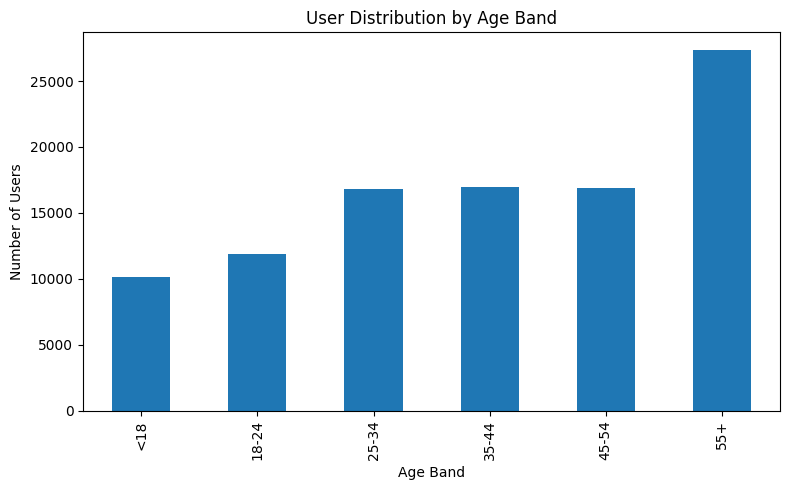

In [82]:
import matplotlib.pyplot as plt

users["age_band"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("User Distribution by Age Band")
plt.xlabel("Age Band")
plt.ylabel("Number of Users")
plt.tight_layout()
plt.show()

Finding 1: Users aged 55+ represent the largest customer segment in the platform.

Business Implication: ShopStream serves a substantial mature customer base and should ensure product assortment, UX design, and marketing campaigns address their preferences.

Hypothesis: Older customers may have greater purchasing power and more established online shopping habits, resulting in higher platform adoption.

In [83]:
print(users["gender"].value_counts())

gender
Female    50208
Male      49792
Name: count, dtype: int64


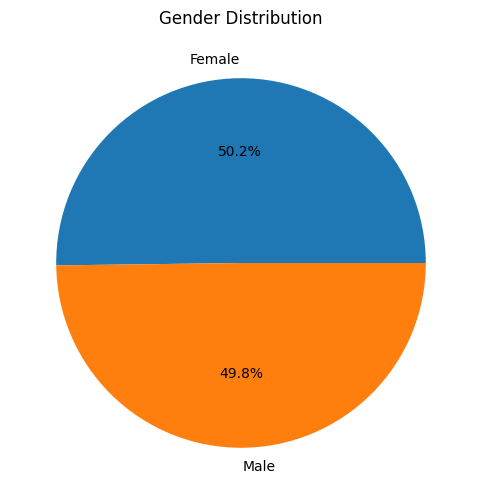

In [84]:
import matplotlib.pyplot as plt

users["gender"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.title("Gender Distribution")
plt.ylabel("")
plt.show()

### Finding 2

What the data shows:
The customer base is almost evenly split between male and female users, with females accounting for 50.2% and males accounting for 49.8%.

Business Implication:
ShopStream does not rely on a single gender segment and should maintain a balanced merchandising and marketing strategy across product categories.

Hypothesis:
The platform's product catalog covers a broad range of customer needs, attracting both male and female shoppers equally.

In [85]:
print(
    users["traffic_source"]
    .value_counts()
)

traffic_source
Search      70075
Organic     15110
Facebook     5816
Email        4947
Display      4052
Name: count, dtype: int64


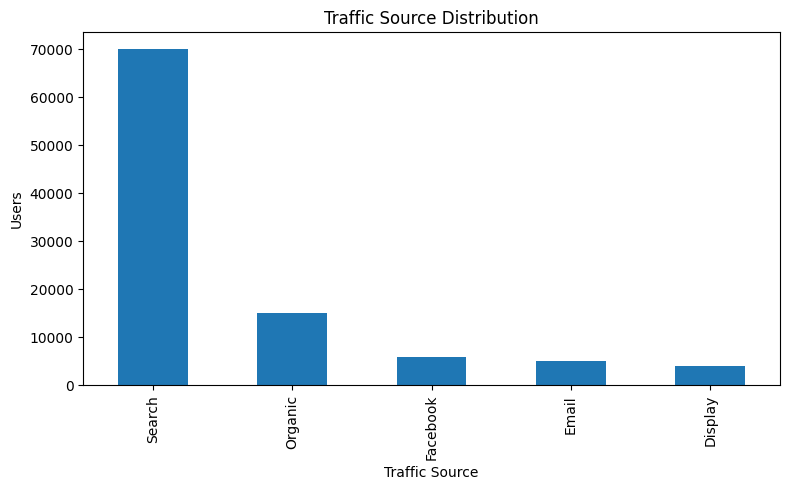

In [86]:
import matplotlib.pyplot as plt

traffic = (
    users["traffic_source"]
    .value_counts()
    .sort_values(ascending=False)
)

traffic.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Traffic Source Distribution")
plt.xlabel("Traffic Source")
plt.ylabel("Users")
plt.tight_layout()
plt.show()

### Finding 3

What the data shows:
Search is the dominant acquisition channel, contributing approximately 70% of all registered users, significantly outperforming Organic, Facebook, Email, and Display channels.

Business Implication:
ShopStream is heavily dependent on search-driven customer acquisition. Any decline in search visibility or paid search performance could materially impact user growth.

Hypothesis:
Strong search performance may be driven by effective SEO, branded search demand, or high-performing paid search campaigns.

In [87]:
top_states = (
    users["state"]
    .value_counts()
    .head(10)
)

print(top_states)

state
Guangdong     5380
England       4034
California    3704
Shanghai      2499
Texas         2468
Zhejiang      2125
Beijing       2123
São Paulo     2119
Hebei         2038
Jiangsu       1894
Name: count, dtype: int64


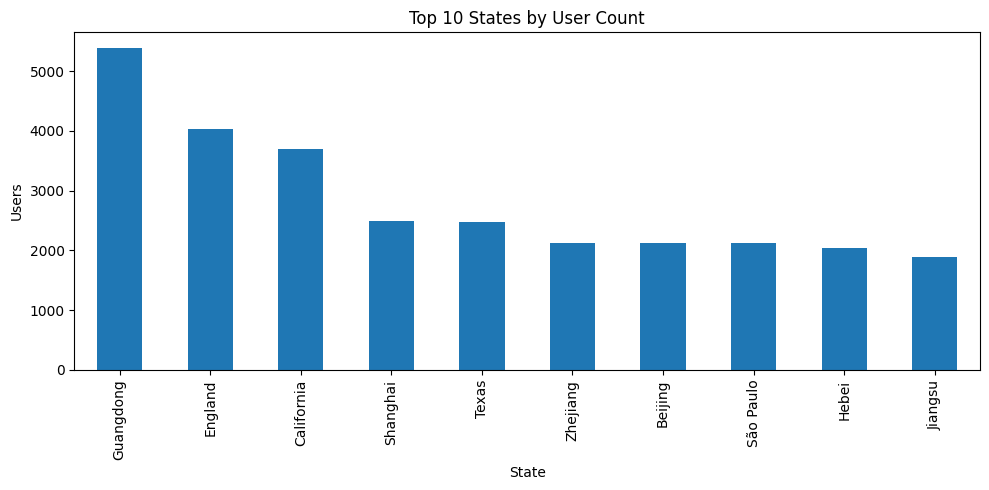

In [88]:
import matplotlib.pyplot as plt

top_states.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 States by User Count")
plt.xlabel("State")
plt.ylabel("Users")
plt.tight_layout()
plt.show()

### Finding 4

What the data shows:
Users are distributed across multiple international regions, with Guangdong, England, and California representing the largest user concentrations.

Business Implication:
ShopStream operates across multiple geographic markets, creating opportunities for localized marketing, inventory planning, and region-specific promotional campaigns.

Hypothesis:
The platform's international presence may be driven by broad product availability and digital acquisition channels that attract users from multiple countries.

In [89]:
users["signup_month"] = (
    users["created_at"]
    .dt.to_period("M")
    .astype(str)
)

monthly_users = (
    users.groupby("signup_month")
    .size()
)

print(monthly_users.head())
print(monthly_users.tail())

signup_month
2019-01    1591
2019-02    1441
2019-03    1639
2019-04    1608
2019-05    1727
dtype: int64
signup_month
2023-09    1620
2023-10    1644
2023-11    1576
2023-12    1635
2024-01    3276
dtype: int64


C:\Users\OM\AppData\Local\Temp\ipykernel_3156\698778397.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .dt.to_period("M")


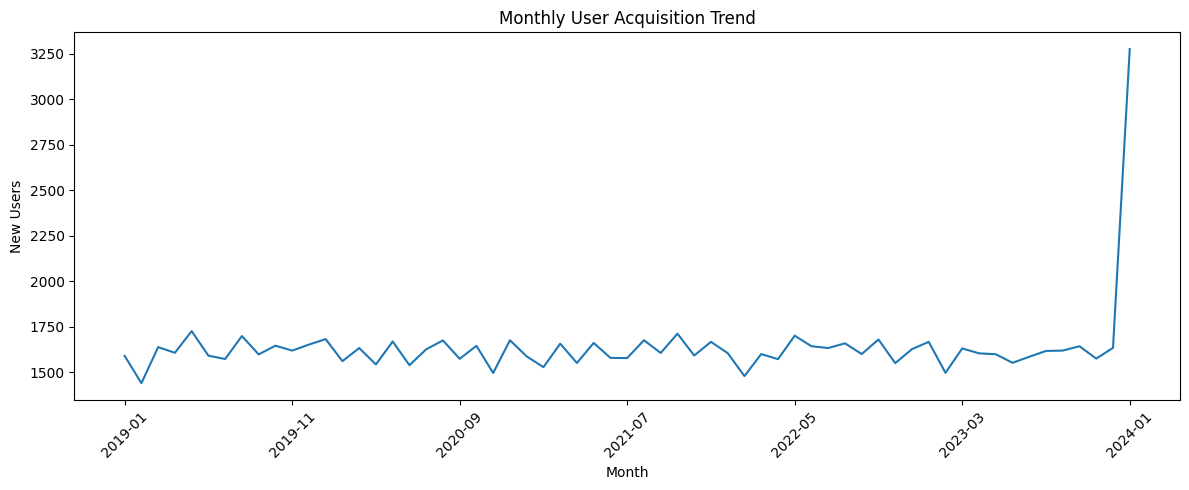

In [90]:
import matplotlib.pyplot as plt

monthly_users.plot(
    figsize=(12,5)
)

plt.title("Monthly User Acquisition Trend")
plt.xlabel("Month")
plt.ylabel("New Users")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Finding 5

What the data shows:
Monthly user acquisition remained remarkably stable between 2019 and 2023, averaging roughly 1,500–1,700 new users per month. However, January 2024 shows an unusually large spike in registrations.

Business Implication:
The platform demonstrates consistent user acquisition performance, indicating a mature and predictable growth engine. The January 2024 surge should be investigated before being used for forecasting.

Hypothesis:
The January 2024 spike may be caused by a major marketing campaign, data collection cutoff effects, bulk user imports, or seasonal shopping activity rather than normal organic growth.
Analyst Note:
January 2024 acquisition volume appears significantly higher than historical patterns and should be treated as a potential outlier until validated.

C:\Users\OM\AppData\Local\Temp\ipykernel_3156\3768413087.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .dt.to_period("M")


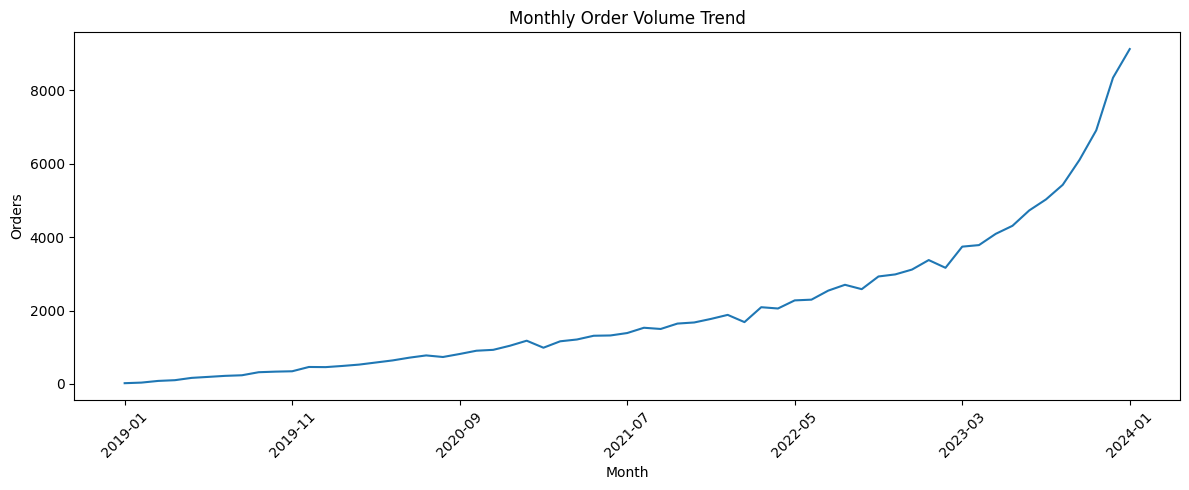

In [91]:
orders["order_month"] = (
    orders["created_at"]
    .dt.to_period("M")
    .astype(str)
)

monthly_orders = (
    orders.groupby("order_month")
    .size()
)

monthly_orders.plot(
    figsize=(12,5)
)

plt.title("Monthly Order Volume Trend")
plt.xlabel("Month")
plt.ylabel("Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [92]:
print(
    order_items["status"]
    .value_counts()
)

status_pct = (
    order_items["status"]
    .value_counts(normalize=True)
    * 100
)

print(
    round(status_pct,2)
)

status
Shipped       54440
Complete      45609
Processing    36388
Cancelled     27090
Returned      18232
Name: count, dtype: int64
status
Shipped       29.95
Complete      25.09
Processing    20.02
Cancelled     14.90
Returned      10.03
Name: proportion, dtype: float64


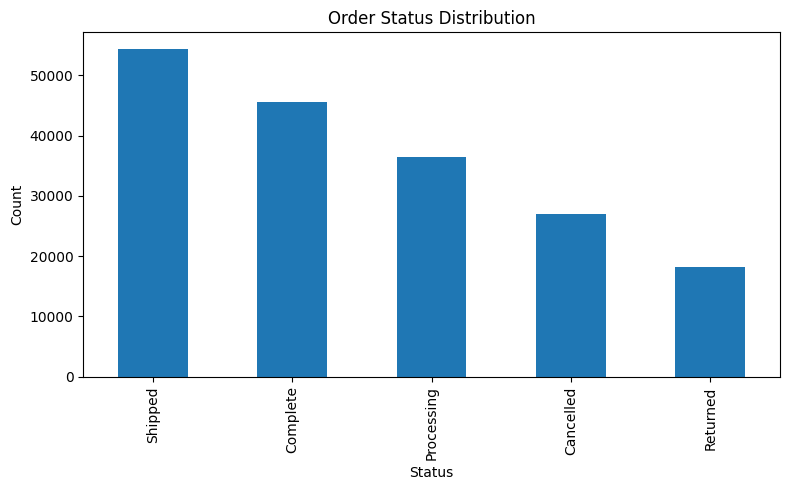

In [93]:
order_items["status"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Order Status Distribution")
plt.xlabel("Status")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [94]:
aov_df = (
    order_items
    .groupby("order_id")["sale_price"]
    .sum()
    .reset_index()
)

overall_aov = aov_df["sale_price"].mean()

print("Overall AOV:", round(overall_aov,2))

Overall AOV: 86.46


### Finding 6

What the data shows:
Monthly order volume increased consistently from 2019 through 2023, with accelerated growth observed during the final year of the dataset.

Business Implication:
ShopStream is successfully scaling transaction volume over time, indicating growing customer engagement and increasing platform adoption.

Hypothesis:
The growth may be driven by successful customer acquisition efforts, improved product assortment, and increasing repeat purchase behavior.

### Finding 7

What the data shows:
Only 25.1% of order items are marked as Complete, while approximately 15% are Cancelled and 10% are Returned.

Business Implication:
Order cancellations and returns represent a meaningful operational cost and potential customer experience challenge. Reducing these rates could significantly improve profitability.

Hypothesis:
Returns may be driven by product fit, customer expectations, or fulfillment issues, while cancellations may result from inventory availability or checkout friction.

### Finding 8

What the data shows:
The average order value (AOV) is ₹86.46 per order.

Business Implication:
Revenue growth can be achieved through both customer acquisition and strategies that increase basket size, such as bundling, cross-selling, and personalized recommendations.

Hypothesis:
The relatively modest AOV suggests customers often purchase a limited number of products per transaction rather than making large basket purchases.

In [95]:
category_revenue = (
    order_items
    .merge(
        products[["id","category"]],
        left_on="product_id",
        right_on="id",
        how="left"
    )
    .groupby("category")["sale_price"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(category_revenue)

category
Outerwear & Coats                1.301571e+06
Jeans                            1.253644e+06
Sweaters                         8.426515e+05
Suits & Sport Coats              6.667673e+05
Fashion Hoodies & Sweatshirts    6.493528e+05
Swim                             6.467387e+05
Sleep & Lounge                   5.373921e+05
Shorts                           5.120695e+05
Tops & Tees                      4.915514e+05
Dresses                          4.644168e+05
Name: sale_price, dtype: float64


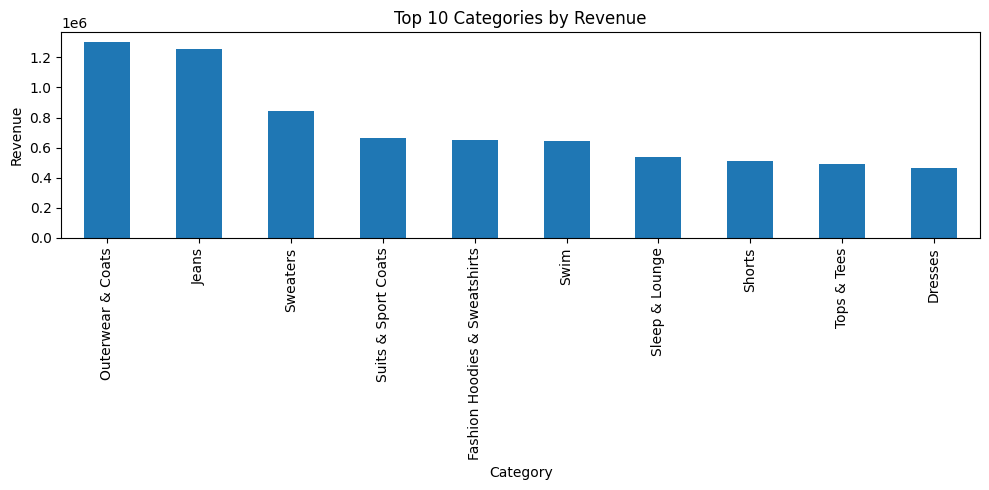

In [96]:
category_revenue.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 Categories by Revenue")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

In [97]:
margin_analysis = (
    order_items
    .merge(
        products[["id","category"]],
        left_on="product_id",
        right_on="id"
    )
    .groupby("category")["gross_margin"]
    .mean()
    .sort_values(ascending=False)
)

print(margin_analysis.head(10))

category
Outerwear & Coats      80.494545
Suits & Sport Coats    76.379485
Blazers & Jackets      56.592524
Dresses                46.722366
Jeans                  45.905812
Suits                  45.326891
Sweaters               38.815841
Skirts                 32.505737
Pants                  32.227709
Clothing Sets          30.876625
Name: gross_margin, dtype: float64


price_tier
Budget     14988
Mid        10130
Premium     4002
Name: count, dtype: int64


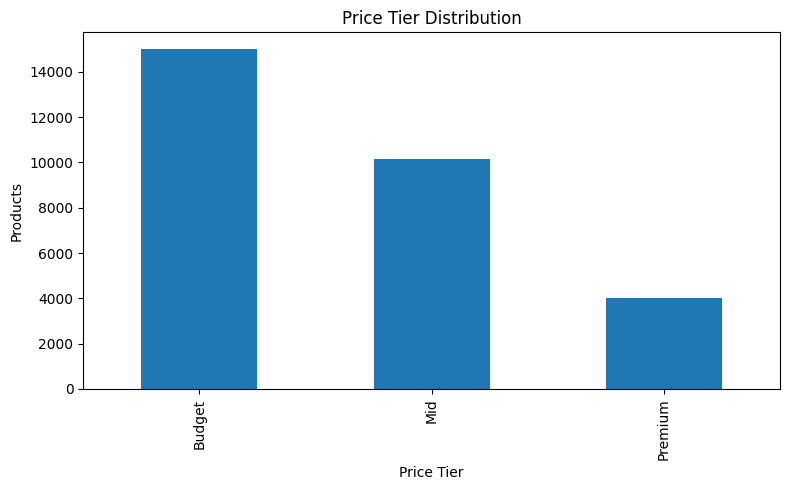

In [98]:
print(
    products["price_tier"]
    .value_counts()
)

products["price_tier"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Price Tier Distribution")
plt.xlabel("Price Tier")
plt.ylabel("Products")
plt.tight_layout()
plt.show()

### Finding 9

What the data shows:
Outerwear & Coats and Jeans are the highest revenue-generating categories, each contributing more than ₹1.2 million in revenue.

Business Implication:
A significant share of revenue is concentrated within a small number of product categories. These categories should receive priority in inventory planning, promotions, and merchandising decisions.

Hypothesis:
These categories likely combine strong customer demand with relatively higher selling prices, resulting in greater revenue contribution.

### Finding 10

What the data shows:
Outerwear & Coats and Suits & Sport Coats generate the highest average gross margins, significantly outperforming most other categories.

Business Implication:
Revenue and profitability are aligned within these categories, making them strategically important for long-term growth and marketing investment.

Hypothesis:
Customers may be less price-sensitive in premium apparel segments, allowing higher markup percentages and stronger margins.

### Finding 11

What the data shows:
Budget products account for approximately half of the entire catalog, while premium products represent the smallest segment.

Business Implication:
ShopStream primarily competes in the value and mid-market segments, making affordability a key component of its product strategy.

Hypothesis:
A larger budget assortment may improve conversion rates by appealing to a broader customer base and encouraging repeat purchases.

In [99]:
revenue_df = order_items.merge(
    orders[["order_id", "created_at"]],
    on="order_id",
    how="left"
)

revenue_df["day_of_week"] = (
    pd.to_datetime(
        revenue_df["created_at"],
        format="mixed",
        utc=True
    )
    .dt.day_name()
)

revenue_by_day = (
    revenue_df
    .groupby("day_of_week")["sale_price"]
    .sum()
    .reindex([
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
        "Sunday"
    ])
)

print(revenue_by_day)

KeyError: 'created_at'

In [100]:
print(order_items.columns.tolist())

['id', 'order_id', 'user_id', 'product_id', 'inventory_item_id', 'status', 'created_at', 'shipped_at', 'delivered_at', 'returned_at', 'sale_price', 'sale_price_capped', 'product_master_id', 'cost', 'gross_margin']


In [101]:
print(orders.columns.tolist())

['order_id', 'user_id', 'status', 'gender', 'created_at', 'returned_at', 'shipped_at', 'delivered_at', 'num_of_item', 'order_completion_days', 'is_returned', 'order_month', 'order_quarter', 'order_year']


In [102]:
print(revenue_df.columns)

Index(['id', 'order_id', 'user_id', 'product_id', 'inventory_item_id',
       'status', 'created_at_x', 'shipped_at', 'delivered_at', 'returned_at',
       'sale_price', 'sale_price_capped', 'product_master_id', 'cost',
       'gross_margin', 'created_at_y'],
      dtype='object')


In [103]:
order_items["day_of_week"] = (
    pd.to_datetime(
        order_items["created_at"],
        format="mixed",
        utc=True
    )
    .dt.day_name()
)

revenue_by_day = (
    order_items
    .groupby("day_of_week")["sale_price"]
    .sum()
    .reindex([
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
        "Sunday"
    ])
)

print(revenue_by_day)

day_of_week
Monday       1.597354e+06
Tuesday      1.537775e+06
Wednesday    1.554187e+06
Thursday     1.539191e+06
Friday       1.521525e+06
Saturday     1.513164e+06
Sunday       1.563922e+06
Name: sale_price, dtype: float64


In [104]:
print(order_items.columns.tolist())

['id', 'order_id', 'user_id', 'product_id', 'inventory_item_id', 'status', 'created_at', 'shipped_at', 'delivered_at', 'returned_at', 'sale_price', 'sale_price_capped', 'product_master_id', 'cost', 'gross_margin', 'day_of_week']


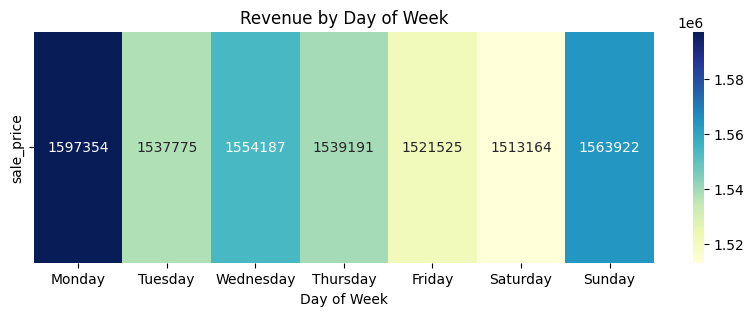

In [105]:
import seaborn as sns
import matplotlib.pyplot as plt

heatmap_data = revenue_by_day.to_frame().T

plt.figure(figsize=(10,3))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

plt.title("Revenue by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("")

plt.show()

In [106]:
order_items["created_at"] = pd.to_datetime(
    order_items["created_at"],
    format="mixed",
    utc=True
)

order_items["delivered_at"] = pd.to_datetime(
    order_items["delivered_at"],
    format="mixed",
    utc=True
)

delivery_df = order_items[
    order_items["delivered_at"].notna()
].copy()

delivery_df["delivery_days"] = (
    delivery_df["delivered_at"]
    - delivery_df["created_at"]
).dt.days

print(
    delivery_df["delivery_days"]
    .describe()
)

count    63841.000000
mean         2.545950
std          2.221595
min         -4.000000
25%          1.000000
50%          3.000000
75%          4.000000
max          8.000000
Name: delivery_days, dtype: float64


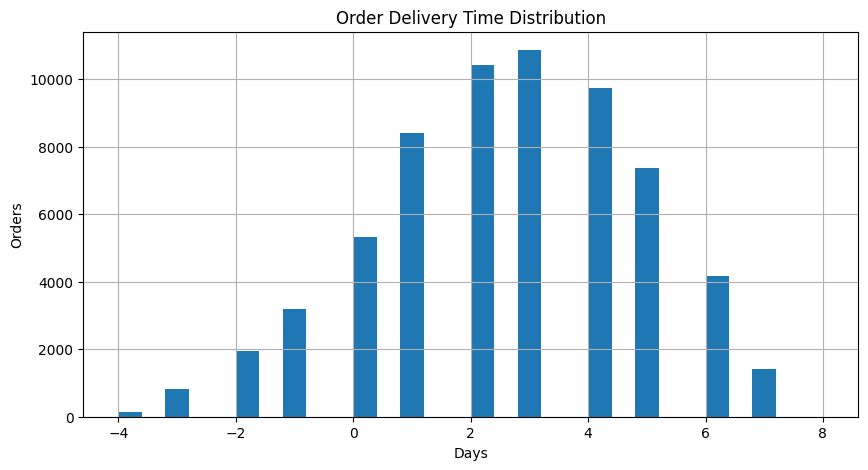

In [107]:
plt.figure(figsize=(10,5))

delivery_df["delivery_days"].hist(
    bins=30
)

plt.title("Order Delivery Time Distribution")
plt.xlabel("Days")
plt.ylabel("Orders")

plt.show()

In [108]:
delivery_df["delivery_days"].describe()

count    63841.000000
mean         2.545950
std          2.221595
min         -4.000000
25%          1.000000
50%          3.000000
75%          4.000000
max          8.000000
Name: delivery_days, dtype: float64

C:\Users\OM\AppData\Local\Temp\ipykernel_3156\1154280831.py:9: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .dt.to_period("M")


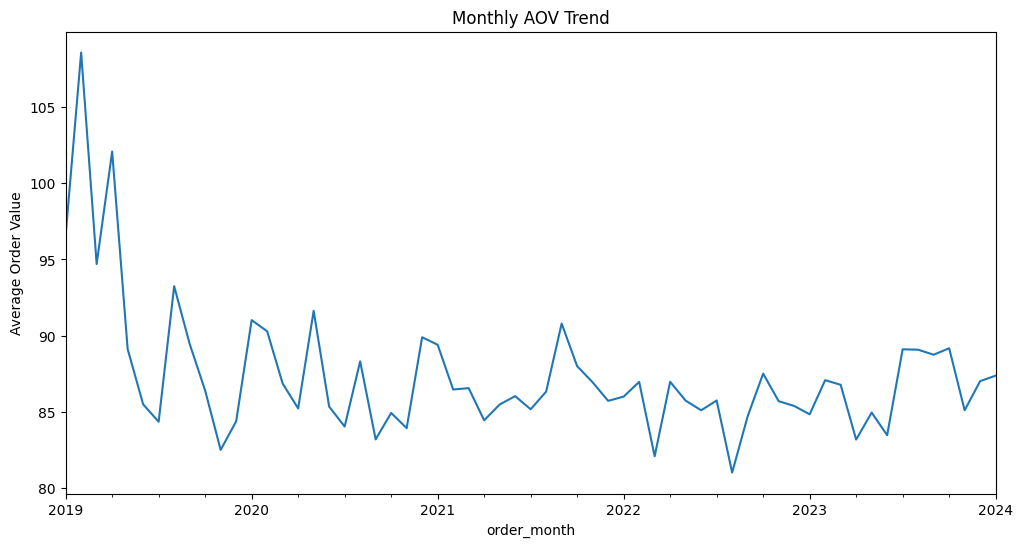

In [111]:
orders["created_at"] = pd.to_datetime(
    orders["created_at"],
    format="mixed",
    utc=True
)

orders["order_month"] = (
    orders["created_at"]
    .dt.to_period("M")
)

monthly_aov = (
    order_items
    .groupby("order_id")["sale_price"]
    .sum()
    .reset_index()
)

monthly_aov = monthly_aov.merge(
    orders[["order_id", "order_month"]],
    on="order_id",
    how="left"
)

monthly_aov = (
    monthly_aov
    .groupby("order_month")["sale_price"]
    .mean()
)

monthly_aov.plot(
    figsize=(12,6)
)

plt.title("Monthly AOV Trend")
plt.ylabel("Average Order Value")
plt.show()

In [112]:
delivery_df = order_items.copy()

delivery_df["shipped_at"] = pd.to_datetime(
    delivery_df["shipped_at"],
    format="mixed",
    utc=True
)

delivery_df["delivered_at"] = pd.to_datetime(
    delivery_df["delivered_at"],
    format="mixed",
    utc=True
)

delivery_df["delivery_days"] = (
    delivery_df["delivered_at"]
    - delivery_df["shipped_at"]
).dt.days

delivery_df = delivery_df[
    delivery_df["delivery_days"].notna()
]

print(
    delivery_df["delivery_days"]
    .describe()
)

count    63841.000000
mean         2.013784
std          1.417355
min          0.000000
25%          1.000000
50%          2.000000
75%          3.000000
max          4.000000
Name: delivery_days, dtype: float64


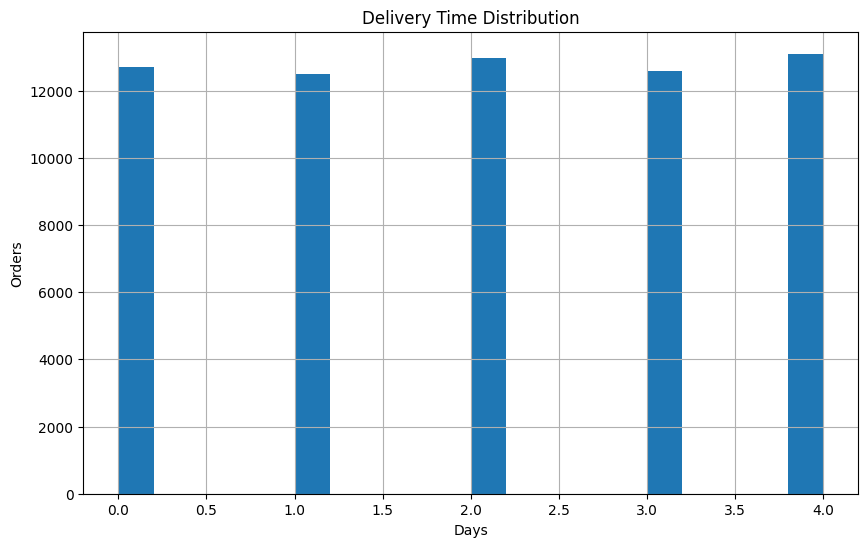

In [113]:
plt.figure(figsize=(10,6))

delivery_df["delivery_days"].hist(
    bins=20
)

plt.title(
    "Delivery Time Distribution"
)
plt.xlabel("Days")
plt.ylabel("Orders")

plt.show()